# Niger Delta — pyflare quickstart

> A 5-minute end-to-end walkthrough: from the World Bank's annual
> GGFR estimates to a peer-reviewable CO₂-equivalent headline number
> for Nigerian gas flaring. Runs without EOG credentials by using a
> synthetic VNF detection dataset for the Niger Delta — replace the
> synthetic block with `pf.fetch_vnf_nightly()` once your EOG
> license is approved.

**Status:** validated against pyflare v0.1.0 + 2025 GGFR release
(data through 2024).


## Setup

```bash
pip install pyflare-africa[viz,notebooks]   # or `pip install -e ".[viz,notebooks]"` if developing
```

This notebook assumes `matplotlib` is available; everything else is
in pyflare's core install.


## Data attribution

This notebook is structured around the VIIRS Nightfire (VNF)
product. The synthetic VNF block in §3 is a stand-in until your
EOG academic license is approved. **When you swap that block for
`pf.fetch_vnf_nightly()`, the following attribution applies to
every chart and table rendered below it:**

> This product was made utilizing VIIRS Nightfire (VNF) nightly
> data produced by the Earth Observation Group, Payne Institute
> for Public Policy, Colorado School of Mines.

For tight space, use: *"Source: VIIRS Nightfire, Colorado School
of Mines."*

Annual flaring volumes are published by the World Bank
Global Gas Flaring Reduction Partnership. Pyflare cites
Elvidge et al. (2013) and Elvidge et al. (2016) — see
[`LICENSING_NOTES.md`](../LICENSING_NOTES.md) for the full set of
VNF license obligations (including: no raw VNF redistribution,
weekly-minimum public temporal aggregation, year-N volume
publication only after EOG publishes year-N).


In [1]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyflare as pf
from pyflare.analysis import (
    classify_detection_type,
    aggregate_to_sites,
    estimate_flared_volume,
    volume_to_co2eq,
)

print(f"pyflare {pf.__version__}")


pyflare 0.1.0


## 1. Annual flaring trend, Nigeria 2012–2024

`fetch_ggfr_annual()` pulls the live World Bank GGFR workbook,
melts it to long format, and normalises country names. No
authentication required.


In [2]:
annual = pf.fetch_ggfr_annual()
nigeria = annual[annual["country"] == "Nigeria"].sort_values("year")
nigeria_recent = nigeria.tail(8).reset_index(drop=True)
nigeria_recent


,country,year,bcm_flared
0,Nigeria,2017,7.646269
1,Nigeria,2018,7.538876
2,Nigeria,2019,7.759663
3,Nigeria,2020,7.194656
4,Nigeria,2021,6.626851
5,Nigeria,2022,5.318368
6,Nigeria,2023,5.786464
7,Nigeria,2024,6.479560


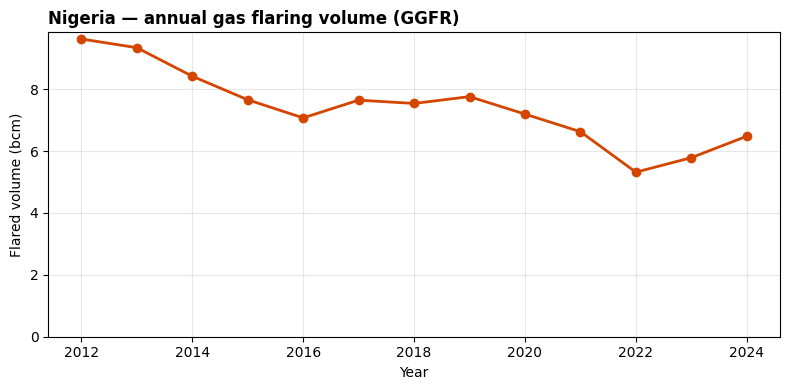

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(nigeria["year"], nigeria["bcm_flared"], marker="o", color="#d44500", linewidth=2)
ax.set_title("Nigeria — annual gas flaring volume (GGFR)", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Flared volume (bcm)")
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


## 2. African context — top-5 producers in 2024


In [4]:
african_producers = pf.list_supported_countries()
top5 = (
    annual[(annual["country"].isin(african_producers)) & (annual["year"] == 2024)]
    .nlargest(5, "bcm_flared")
    .reset_index(drop=True)
)
top5


,country,year,bcm_flared
0,Algeria,2024,7.88203
1,Nigeria,2024,6.47956
2,Libya,2024,6.27505
3,Angola,2024,2.06090
4,Republic of Congo,2024,1.93604


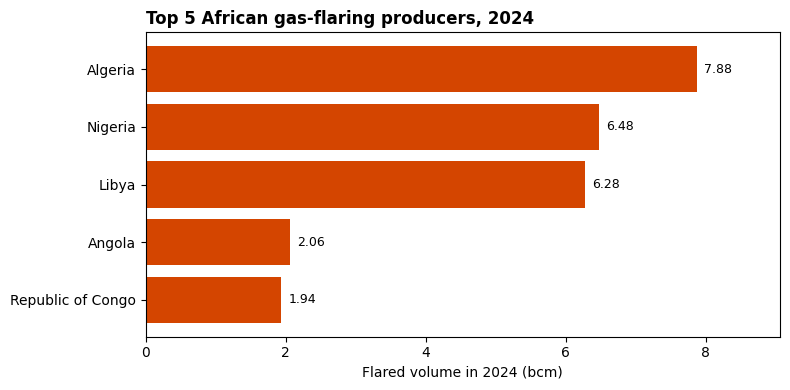

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(top5["country"][::-1], top5["bcm_flared"][::-1], color="#d44500")
ax.set_title("Top 5 African gas-flaring producers, 2024", loc="left", fontsize=12, fontweight="bold")
ax.set_xlabel("Flared volume in 2024 (bcm)")
for bar, val in zip(bars, top5["bcm_flared"][::-1]):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2, f"{val:.2f}", va="center", fontsize=9)
ax.set_xlim(right=top5["bcm_flared"].max() * 1.15)
plt.tight_layout()
plt.show()


## 3. Per-flare detail — synthetic VNF stand-in

The real `pf.fetch_vnf_nightly()` call requires EOG credentials
(currently pending under the new VNF license-based flow as of Jan
2025). Until those arrive, we synthesise a plausible Niger Delta
nightly detection set so the rest of the pipeline can be exercised
end-to-end. **Replace the next cell with the real fetch once your
license is in hand:**

```python
import os
os.environ["EOG_USERNAME"] = "..."
os.environ["EOG_PASSWORD"] = "..."
detections = pf.fetch_vnf_nightly("2024-08-15", satellite="snpp")
nigerian_detections = pf.filter_country(detections, "Nigeria")
```


In [6]:
rng = np.random.default_rng(42)

# Approximate coordinates of major Niger Delta flare facilities.
sites_truth = [
    ("Bonny LNG",  7.16, 4.41),
    ("Forcados",   5.36, 5.34),
    ("Brass",      6.24, 4.32),
    ("Escravos",   5.18, 5.65),
    ("Onne",       7.16, 4.71),
    ("Soku",       6.66, 4.38),
]

records = []
for name, lon, lat in sites_truth:
    n = rng.integers(8, 16)  # 8-15 nightly observations per site
    for _ in range(n):
        records.append({
            "site_truth": name,
            "longitude": lon + rng.normal(0, 0.005),  # ~500m jitter
            "latitude":  lat + rng.normal(0, 0.005),
            "temperature_k":   max(1500, rng.normal(1850, 150)),
            "radiant_heat_mw": rng.uniform(20, 80),
            "obs_date": pd.Timestamp("2024-08-15") + pd.Timedelta(days=int(rng.integers(0, 14))),
        })
# Sprinkle in some wildfires for the classifier to reject.
for _ in range(15):
    records.append({
        "site_truth": "wildfire",
        "longitude": rng.uniform(2.7, 14.7),
        "latitude":  rng.uniform(4.3, 13.9),
        "temperature_k":   rng.normal(900, 100),
        "radiant_heat_mw": rng.uniform(5, 25),
        "obs_date": pd.Timestamp("2024-08-15") + pd.Timedelta(days=int(rng.integers(0, 14))),
    })

vnf_synthetic = pd.DataFrame(records)
print(f"Synthesised {len(vnf_synthetic)} detections "
      f"(mean temp {vnf_synthetic['temperature_k'].mean():.0f} K)")


Synthesised 80 detections (mean temp 1681 K)


### Classify, filter, cluster

Threshold-based classification (Elvidge et al., 2013) splits the
detections into flares vs wildfires; greedy clustering rolls
co-located nightly detections into persistent flare sites.


In [7]:
classified = classify_detection_type(vnf_synthetic)
flares = classified[classified["detection_type"] == "flare"].copy()
sites = aggregate_to_sites(flares)

print(f"  Total detections:  {len(vnf_synthetic)}")
print(f"  Classified flares: {len(flares)}")
print(f"  Clustered sites:   {len(sites)} (truth: 6 facilities)")
sites


  Total detections:  80
  Classified flares: 65
  Clustered sites:   14 (truth: 6 facilities)


,site_id,longitude,latitude,n_detections,mean_rh_mw,total_rh_mw
0,3,6.240634,4.316544,11,49.252457,541.777030
1,6,5.179956,5.648743,11,51.008415,561.092560
2,2,5.357530,5.340694,9,49.617179,446.554615
3,13,6.658483,4.377951,9,52.248003,470.232030
4,0,7.157795,4.409902,6,48.166911,289.001466
5,9,7.161725,4.706611,5,46.586434,232.932172
6,7,5.186870,5.647248,3,42.059458,126.178375
7,10,7.155007,4.704880,3,49.082876,147.248629
8,1,7.163367,4.409796,2,46.597366,93.194732
9,12,6.666523,4.372420,2,71.576657,143.153314


In [8]:
# Estimate volumes per site (Elvidge et al., 2016 RH→volume regression).
volumes = estimate_flared_volume(sites, observation_days=14)
site_total_bcm = volumes["estimated_volume_bcm"].sum()
print(f"Sum of synthetic-site flared volume estimates: {site_total_bcm:.4f} bcm")
print("(Synthetic, not comparable to GGFR Nigeria-wide total — illustrative only.)")
volumes[["site_id", "longitude", "latitude", "n_detections", "estimated_volume_bcm"]]


Sum of synthetic-site flared volume estimates: 0.1323 bcm
(Synthetic, not comparable to GGFR Nigeria-wide total — illustrative only.)


,site_id,longitude,latitude,n_detections,estimated_volume_bcm
0,3,6.240634,4.316544,11,0.022027
1,6,5.179956,5.648743,11,0.022813
2,2,5.357530,5.340694,9,0.018156
3,13,6.658483,4.377951,9,0.019118
4,0,7.157795,4.409902,6,0.011750
5,9,7.161725,4.706611,5,0.009470
6,7,5.186870,5.647248,3,0.005130
7,10,7.155007,4.704880,3,0.005987
8,1,7.163367,4.409796,2,0.003789
9,12,6.666523,4.372420,2,0.005820


## 4. Headline number — Niger Delta CO₂-equivalent, 2024

Using `volume_to_co2eq()` against the **GGFR-reported** Nigeria
2024 flared volume (not the synthetic per-site sum), under three
published methane-slip assumptions.


In [9]:
ng_2024_bcm = float(nigeria.loc[nigeria["year"] == 2024, "bcm_flared"].iloc[0])

scenarios = [
    (0.02, "IPCC AR6 default"),
    (0.05, "pyflare default / Plant et al. 2022 mid"),
    (0.09, "Plant et al. 2022 upper bound"),
]

rows = []
for slip, label in scenarios:
    mt = volume_to_co2eq(ng_2024_bcm, slip)
    rows.append({"slip": slip, "source": label, "MtCO2e": round(mt, 2)})

headline = pd.DataFrame(rows)
print(f"Nigeria flared volume (GGFR 2024): {ng_2024_bcm:.2f} bcm")
print()
headline


Nigeria flared volume (GGFR 2024): 6.48 bcm



,slip,source,MtCO2e
0,0.02,IPCC AR6 default,18.96
1,0.05,pyflare default / Plant et al. 2022 mid,22.62
2,0.09,Plant et al. 2022 upper bound,27.50


### Poster framing candidate

> **Nigeria's 2024 gas flaring (6.48 bcm of natural gas) translates
> to roughly 19–28 megatonnes of CO₂-equivalent emissions per year,
> depending on which methane slip assumption you adopt. The spread
> is itself the argument for satellite measurement: the answer is
> not in dispute by an order of magnitude, but the difference
> between the IPCC AR6 default (2 %) and recent satellite-derived
> slip rates (5–9 %) is roughly 50 % of the headline.**

The defensible quote for the poster is the range, with the slip
choice made explicit. Reviewers from atmospheric chemistry will
nod; reviewers from advocacy will appreciate the upper bound.

## 5. Next steps

- Replace the synthetic VNF cell with `pf.fetch_vnf_nightly()` once
  the EOG license arrives. **Before re-publishing this notebook
  with real VNF outputs, confirm:** (a) the displayed year is
  cleared at https://eogdata.mines.edu/products/vnf/global_gas_flare.html,
  (b) any temporal display is aggregated to weekly minimum, and
  (c) the data-attribution cell above is in place.
- Run the same notebook for Algeria, Libya, and Angola
  (`02_angola.ipynb`, `03_algeria.ipynb`, `04_libya.ipynb`) —
  target gate G4.
- Cross-validate the synthetic-site clustering against ground-truth
  facility coordinates (Bonny LNG, Forcados, Brass, etc.) once VNF
  detections are real.

---

*Source: VIIRS Nightfire, Colorado School of Mines.* (Applies once
the synthetic VNF block above is replaced with real EOG data.)
